# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: 06

Group Members:
- Richard Christian 13523024
- Kenneth Poenadi Name 13523040
- Ivan Wirawan 13523046
- Bob Kunanda 13523086
- M Zahran Ramadhan 13523104

## Import Libraries

In [2312]:
# ==================== IMPORTS ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import PowerTransformer, QuantileTransformer, Normalizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.base import BaseEstimator, TransformerMixin

# Imbalanced data handling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Model interpretation
import shap

# Deep learning for autoencoders
try:
    from tensorflow import keras
    from tensorflow.keras import layers
    KERAS_AVAILABLE = True
except:
    KERAS_AVAILABLE = False
    print("Warning: TensorFlow not available. Autoencoder will be disabled.")

# Model persistence
import joblib
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 67

## Import Dataset

In [2313]:
# Example of reading a csv file from a gdrive link

# Take the file id from the gdrive file url
# https://drive.google.com/file/d/1ZUtiaty9RPXhpz5F2Sy3dFPHF4YIt5iU/view?usp=sharing => The file id is 1ZUtiaty9RPXhpz5F2Sy3dFPHF4YIt5iU
# and then put it in this format:
# https://drive.google.com/uc?id={file_id}
# Don't forget to change the access to public

df = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

In [2314]:
# profile = ProfileReport(df, title="EDA Report", explorative=True)
# profile.to_notebook_iframe()


In [2315]:
categorical_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance\t', 'Previous qualification',  'Gender', 'Nacionality', 
    'Mother\'s qualification', 'Father\'s qualification', 'Mother\'s occupation', 'Father\'s occupation',
    'Educational special needs', 'International',
    'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Displaced'
]

df[categorical_cols] = df[categorical_cols].astype(str)
df_test[categorical_cols] = df_test[categorical_cols].astype(str)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3096 entries, 0 to 3095
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Student_ID                                      3096 non-null   int64  
 1   Marital status                                  3096 non-null   object 
 2   Application mode                                3096 non-null   object 
 3   Application order                               3096 non-null   object 
 4   Course                                          3096 non-null   object 
 5   Daytime/evening attendance	                     3096 non-null   object 
 6   Previous qualification                          3096 non-null   object 
 7   Previous qualification (grade)                  3096 non-null   float64
 8   Nacionality                                     3096 non-null   object 
 9   Mother's qualification                   

In [2316]:
def top3_categories_per_target(df, target_col="Target"):
    """
    For every categorical column in df (except the target),
    prints the top 3 most frequent categories per target class.
    """
    df = df.copy()

    # Identify categorical columns
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    # Remove target from list
    if target_col in categorical_cols:
        categorical_cols.remove(target_col)

    print("===== TOP 3 CATEGORIES FOR EACH TARGET CLASS =====\n")

    for col in categorical_cols:
        print(f"\n--- Column: {col} ---")

        # Group by target and category count
        grouped = df.groupby([target_col, col]).size().reset_index(name="count")

        # For each target label, show top 3
        for target_value in df[target_col].unique():
            subset = grouped[grouped[target_col] == target_value].sort_values("count", ascending=False).head(3)

            print(f"\nTarget = {target_value}:")
            if subset.empty:
                print("  (No data)")
            else:
                for _, row in subset.iterrows():
                    print(f"  {row[col]} → {row['count']} times")


# Run it
top3_categories_per_target(df)

===== TOP 3 CATEGORIES FOR EACH TARGET CLASS =====


--- Column: Marital status ---

Target = Graduate:
  1 → 1415 times
  2 → 102 times
  4 → 23 times

Target = Dropout:
  1 → 830 times
  2 → 127 times
  4 → 29 times

Target = Enrolled:
  1 → 513 times
  2 → 30 times
  4 → 10 times

--- Column: Application mode ---

Target = Graduate:
  1 → 765 times
  17 → 310 times
  39 → 151 times

Target = Dropout:
  39 → 308 times
  1 → 238 times
  17 → 184 times

Target = Enrolled:
  1 → 215 times
  17 → 115 times
  39 → 79 times

--- Column: Application order ---

Target = Graduate:
  1 → 979 times
  2 → 212 times
  3 → 123 times

Target = Dropout:
  1 → 738 times
  2 → 109 times
  3 → 52 times

Target = Enrolled:
  1 → 398 times
  2 → 67 times
  3 → 47 times

--- Column: Course ---

Target = Graduate:
  9500 → 373 times
  9238 → 181 times
  9773 → 134 times

Target = Dropout:
  9991 → 101 times
  9147 → 93 times
  9500 → 77 times

Target = Enrolled:
  9147 → 80 times
  9500 → 73 times
  9085 →

In [2317]:
df.skew(numeric_only=True)


Student_ID                                        0.009088
Previous qualification (grade)                    0.299831
Admission grade                                   0.529363
Age at enrollment                                 2.081474
Curricular units 1st sem (credited)               4.188695
Curricular units 1st sem (enrolled)               1.588180
Curricular units 1st sem (evaluations)            0.886651
Curricular units 1st sem (approved)               0.772061
Curricular units 1st sem (grade)                 -1.548017
Curricular units 1st sem (without evaluations)    7.748450
Curricular units 2nd sem (credited)               4.647403
Curricular units 2nd sem (enrolled)               0.713280
Curricular units 2nd sem (evaluations)            0.334332
Curricular units 2nd sem (approved)               0.299546
Curricular units 2nd sem (grade)                 -1.283620
Curricular units 2nd sem (without evaluations)    7.767834
Unemployment rate                                 0.2125

### Skewness Analysis and Correction

Skewness measures the asymmetry of a distribution. Features with high skewness can negatively impact model performance, especially for algorithms that assume normally distributed data (like Logistic Regression, SVM, and Linear models).

**Skewness values:**
- **-0.5 to 0.5**: Fairly symmetric (no transformation needed)
- **0.5 to 1** or **-1 to -0.5**: Moderately skewed (consider transformation)
- **> 1** or **< -1**: Highly skewed (transformation recommended)

**Common transformations:**
- **Log transformation**: For right-skewed data (positive skew)
- **Square root**: For moderate right skew
- **Box-Cox**: Automatic optimal transformation
- **Yeo-Johnson**: Like Box-Cox but handles zero and negative values

In [2318]:
# ==================== SKEWNESS CORRECTION ====================
from sklearn.preprocessing import PowerTransformer

# Create a copy to apply transformations
def skewness_correction(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Remove target and ID if present
    numerical_cols = [col for col in numerical_cols if col not in ['Target', 'Student_ID']]

    # Calculate skewness
    skewness = df[numerical_cols].skew().sort_values(ascending=False)

    df_transformed = df.copy()

    # Apply Yeo-Johnson transformation to highly and moderately skewed features
    skewed_features = skewness[abs(skewness) > 0.5].index.tolist()

    print(f"\nApplying Yeo-Johnson transformation to {len(skewed_features)} skewed features...")

    if len(skewed_features) > 0:
        # Yeo-Johnson works with positive, zero, and negative values
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        
        # Transform only the skewed features
        df_transformed[skewed_features] = pt.fit_transform(df[skewed_features])
        
        # Calculate new skewness
        new_skewness = df_transformed[skewed_features].skew().sort_values(ascending=False)
        
        # Compare before and after
        comparison = pd.DataFrame({
            'Before': skewness[skewed_features],
            'After': new_skewness,
            'Improvement': abs(skewness[skewed_features]) - abs(new_skewness)
        }).sort_values('Before', ascending=False)
        
       
        return df_transformed
    else:
        print("No skewed features found!")



### Skewness Transformer Class (for Pipeline)

You can use this class in your sklearn Pipeline to automatically detect and fix skewness during preprocessing.

In [2319]:
class SkewnessTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to fix skewness in numerical features using Yeo-Johnson transformation.
    
    Parameters:
    -----------
    skew_threshold : float
        Absolute skewness threshold above which transformation is applied (default: 0.5)
    method : str
        Transformation method: 'yeo-johnson' or 'box-cox' (default: 'yeo-johnson')
        Note: box-cox only works with positive values, yeo-johnson works with any values
    """
    
    def __init__(self, skew_threshold=0.5, method='yeo-johnson'):
        self.skew_threshold = skew_threshold
        self.method = method
        self.transformer = None
        self.skewed_features = []
        self.original_skewness = {}
        self.transformed_skewness = {}
        
    def fit(self, X, y=None):
        """Identify skewed features and fit transformer"""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Calculate skewness for numerical columns
        skewness = X_df.select_dtypes(include=[np.number]).skew()
        
        # Identify features above threshold
        self.skewed_features = skewness[abs(skewness) > self.skew_threshold].index.tolist()
        self.original_skewness = skewness[self.skewed_features].to_dict()
        
        if len(self.skewed_features) > 0:
            print(f"SkewnessTransformer: Found {len(self.skewed_features)} skewed features (|skew| > {self.skew_threshold})")
            
            # Fit transformer on skewed features
            self.transformer = PowerTransformer(method=self.method, standardize=False)
            self.transformer.fit(X_df[self.skewed_features])
        else:
            print(f"SkewnessTransformer: No skewed features found (threshold={self.skew_threshold})")
        
        return self
    
    def transform(self, X):
        """Apply transformation to skewed features"""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        if len(self.skewed_features) > 0 and self.transformer is not None:
            # Transform only the skewed features
            X_df[self.skewed_features] = self.transformer.transform(X_df[self.skewed_features])
        
        return X_df if isinstance(X, pd.DataFrame) else X_df.values
    
    def get_skewness_report(self):
        """Get before/after skewness comparison"""
        if len(self.skewed_features) == 0:
            return "No skewed features found."
        
        report = pd.DataFrame({
            'Feature': self.skewed_features,
            'Original_Skewness': [self.original_skewness[f] for f in self.skewed_features],
            'Transformed_Skewness': [self.transformed_skewness.get(f, 0) for f in self.skewed_features]
        })
        return report


# # Example usage in a pipeline:
# from sklearn.pipeline import Pipeline

# pipe = Pipeline([
#     ('skewness_fix', SkewnessTransformer(skew_threshold=0.5)),
#     ('scaler', StandardScaler()),
#     ('model', LogisticRegression())
# ])

# pipe.fit(X_train, y_train)
# predictions = pipe.predict(X_test)

# 1. Split Training Set and Validation Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [2320]:
# Split training set and validation set here, store into variables train_set and val_set.
# Remember to also keep the original training set before splitting. This will come important later.
# train_set, val_set = ...

# pake k-fold cross validatoin aja




# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [2321]:
# Write your code here

### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [2322]:
# ==================== DATA CLEANING ====================
df = df.drop_duplicates()
print(f"Rows after duplicate removal: {df.shape[0]}")

Rows after duplicate removal: 3096


In [2323]:
# Write your code here

### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [2324]:
# ==================== SAFE FEATURE ENGINEERING (HANDLES DIVISION BY ZERO) ====================
import numpy as np
import pandas as pd

def add_features(df):
    """
    Add engineered features with proper handling of division by zero and NaN values.
    Returns a copy of the dataframe with new features.
    """
    df = df.copy()
    
    # Age grouping - convert to numeric immediately
    df["Age_Group"] = pd.cut(
        df["Age at enrollment"],
        bins=[0, 18, 20, 25, 100],
        labels=[1, 2, 3, 4],
        right=True
    ).astype(float)  # Convert to float to avoid categorical dtype issues

    # Semester 1 - Safe division with np.where
    df["S1_Pass_Rate"] = np.where(
        df["Curricular units 1st sem (enrolled)"] > 0,
        df["Curricular units 1st sem (approved)"] / df["Curricular units 1st sem (enrolled)"],
        0.0  # Default to 0 if not enrolled
    )

    df["S1_Evaluation_Attendance_Rate"] = np.where(
        df["Curricular units 1st sem (enrolled)"] > 0,
        df["Curricular units 1st sem (evaluations)"] / df["Curricular units 1st sem (enrolled)"],
        0.0
    )

    df["S1_Avoidance_Rate"] = 1.0 - df["S1_Evaluation_Attendance_Rate"]

    # Semester 2 - Safe division
    df["S2_Pass_Rate"] = np.where(
        df["Curricular units 2nd sem (enrolled)"] > 0,
        df["Curricular units 2nd sem (approved)"] / df["Curricular units 2nd sem (enrolled)"],
        0.0
    )

    df["S2_Evaluation_Attendance_Rate"] = np.where(
        df["Curricular units 2nd sem (enrolled)"] > 0,
        df["Curricular units 2nd sem (evaluations)"] / df["Curricular units 2nd sem (enrolled)"],
        0.0
    )

    df["S2_Avoidance_Rate"] = 1.0 - df["S2_Evaluation_Attendance_Rate"]
    # Progress Metrics
    df["Pass_rate_progress"] = df["S2_Pass_Rate"] - df["S1_Pass_Rate"]
    df["Grade_progress"] = df["Curricular units 2nd sem (grade)"] - df["Curricular units 1st sem (grade)"]
    df["Attendance_progress"] = df["S2_Evaluation_Attendance_Rate"] - df["S1_Evaluation_Attendance_Rate"]
    df["Avoidance_progress"] = df["S2_Avoidance_Rate"] - df["S1_Avoidance_Rate"]
    
    # Replace any remaining inf or nan values with 0
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    return df

# Apply feature engineering
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)
print(f"Original features: {df.shape[1]}")



print(f"After feature engineering: {df.shape[1]}")
print(f"New features added: {df.shape[1] - len(df.columns) + 13}")  # Approximate

# Verify no NaN or inf values
numeric_cols = df.select_dtypes(include=[np.number]).columns
nan_count = df[numeric_cols].isna().sum().sum()
inf_count = np.isinf(df[numeric_cols]).sum().sum()

print(f"\n✓ Quality check:")
print(f"  NaN values: {nan_count}")
print(f"  Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print("  ⚠️ Warning: Found NaN or Inf values, filling with 0...")
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    df[numeric_cols] = df[numeric_cols].fillna(0)
    print("  ✓ Fixed!")
else:
    print("  ✓ All values are valid!")

FEATURE ENGINEERING
Original features: 38
After feature engineering: 38
New features added: 13

✓ Quality check:
  NaN values: 0
  Inf values: 0
  ✓ All values are valid!


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [2325]:
# Example

# from sklearn.base import BaseEstimator, TransformerMixin

# class FeatureEncoder(BaseEstimator, TransformerMixin):

#     def fit(self, X, y=None):

#         # Fit the encoder here

#         return self

#     def transform(self, X):
#         X_encoded = X.copy()

#         # Encode the categorical variables here

#         return X_encoded

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [2326]:
# ==================== MIN-MAX NORMALIZATION (0-1 RANGE) ====================
from sklearn.preprocessing import MinMaxScaler

def min_max_normalization(df):
    """
    Apply Min-Max Normalization to numerical features in the dataframe.
    Returns a copy of the dataframe with normalized features.
    """
    df = df.copy()
    
    # Identify numerical columns (exclude categorical and target)
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols = [col for col in numerical_cols if col not in ['Target', 'Student_ID']]
    
    print(f"\nApplying Min-Max Normalization to {len(numerical_cols)} numerical features...")
    
    # Create MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    # Apply normalization
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    
    return df
# Identify numerical columns (exclude categorical, target, and ID)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['Target', 'Student_ID']]

print("="*60)
print("MIN-MAX NORMALIZATION (0-1 RANGE)")
print("="*60)
print(f"Normalizing {len(numerical_cols)} numerical features...")

# Create MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Apply normalization
df = df.copy()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\n✓ Normalization complete!")
print(f"\nBefore normalization:")
print(df[numerical_cols].describe().loc[['min', 'max']])
print(f"\nAfter normalization:")
print(df[numerical_cols].describe().loc[['min', 'max']])


MIN-MAX NORMALIZATION (0-1 RANGE)
Normalizing 18 numerical features...

✓ Normalization complete!

Before normalization:
     Previous qualification (grade)  Admission grade  Age at enrollment  \
min                             0.0              0.0                0.0   
max                             1.0              1.0                1.0   

     Curricular units 1st sem (credited)  Curricular units 1st sem (enrolled)  \
min                                  0.0                                  0.0   
max                                  1.0                                  1.0   

     Curricular units 1st sem (evaluations)  \
min                                     0.0   
max                                     1.0   

     Curricular units 1st sem (approved)  Curricular units 1st sem (grade)  \
min                                  0.0                               0.0   
max                                  1.0                               1.0   

     Curricular units 1st sem (w

### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [2327]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_fit_transform(df):
    """
    Fit OneHotEncoder on df and transform df.
    Returns encoded_df and encoder.
    """
    df = df.copy()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    categorical_cols = [col for col in categorical_cols if col not in ['Target', 'Student_ID']]

    encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore',
        drop='first'
    )

    encoded_array = encoder.fit_transform(df[categorical_cols])
    encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_encoded], axis=1)

    return df, encoder
def one_hot_transform(df, encoder):
    df = df.copy()
    categorical_cols = [col for col in df.select_dtypes(include=['object', 'category']).columns
                        if col not in ['Target', 'Student_ID']]

    encoded_array = encoder.transform(df[categorical_cols])
    encoded_feature_names = encoder.get_feature_names_out()

    df_encoded = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_encoded], axis=1)

    return df


In [2328]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Student_ID                                      1328 non-null   int64  
 1   Marital status                                  1328 non-null   object 
 2   Application mode                                1328 non-null   object 
 3   Application order                               1328 non-null   object 
 4   Course                                          1328 non-null   object 
 5   Daytime/evening attendance	                     1328 non-null   object 
 6   Previous qualification                          1328 non-null   object 
 7   Previous qualification (grade)                  1328 non-null   float64
 8   Nacionality                                     1328 non-null   object 
 9   Mother's qualification                   

### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [2329]:
from imblearn.over_sampling import SMOTE, RandomOverSampler

def oversample_targets(df, target_col='Target', id_col='Student_ID', random_state=42):
    """
    Oversamples minority classes using SMOTE.
    If SMOTE fails, fallback to RandomOverSampler.
    
    Output:
        df_resampled (DataFrame)
        method_used (string)
    """
    df = df.copy()

    # Separate X and y
    if id_col in df.columns:
        X = df.drop(columns=[target_col, id_col])
    else:
        X = df.drop(columns=[target_col])
    y = df[target_col]

    class_counts = y.value_counts()
    max_count = class_counts.max()

    # Strategy: oversample all minority classes to match the majority
    sampling_strategy = {cls: max_count for cls in class_counts.index}

    # Try SMOTE
    smote = SMOTE(sampling_strategy=sampling_strategy, 
                  random_state=random_state, 
                  k_neighbors=5)

    try:
        X_resampled, y_resampled = smote.fit_resample(X, y)
        method_used = "SMOTE"
    except Exception:
        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=random_state)
        X_resampled, y_resampled = ros.fit_resample(X, y)
        method_used = "RandomOverSampler"
    
    # Build new balanced DataFrame
    df_resampled = pd.concat([
        X_resampled.reset_index(drop=True),
        pd.Series(y_resampled, name=target_col)
    ], axis=1)

    return df_resampled


### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [2330]:
# Write your code here

### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [2331]:
# Write your code here

# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [2332]:
# from sklearn.pipeline import Pipeline

# # Note: You can add or delete preprocessing components from this pipeline

# pipe = Pipeline([("imputer", FeatureImputer()),
#                  ("featurecreator", FeatureCreator()),
#                  ("scaler", FeatureScaler()),
#                  ("encoder", FeatureEncoder())])

# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

In [2333]:
# # Your code should work up until this point
# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

or create your own here

In [2334]:
# ==================== COMPLETE PREPROCESSING PIPELINE WITH FIT/TRANSFORM ====================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

class PreprocessingPipeline(BaseEstimator, TransformerMixin):
    """
    Complete preprocessing pipeline that properly applies fit/transform pattern.
    
    Steps:
    1. Min-Max normalization (0-1 range) for numerical features
    2. One-hot encoding for categorical features  
    3. Oversampling for Dropout and Enrolled (only during fit, not transform)
    
    Usage:
        # Initialize
        preprocessor = PreprocessingPipeline(apply_oversampling=True)
        
        # For training data (fit and optionally oversample)
        X_train_processed, y_train_processed = preprocessor.fit_transform_with_target(X_train, y_train)
        
        # For test data (only transform, no oversampling)
        X_test_processed = preprocessor.transform(X_test)
    """
    
    def __init__(self, apply_oversampling=True):
        self.apply_oversampling = apply_oversampling
        self.numerical_cols = []
        self.categorical_cols = []
        self.column_transformer = None
        self.feature_names_out = []
        self.smote = None
        
    def fit(self, X, y=None):
        """Fit the preprocessing pipeline on training data"""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Ensure all categorical columns are string type (not 'category' dtype)
        for col in X_df.select_dtypes(include=['category']).columns:
            X_df[col] = X_df[col].astype(str)
        
        # Identify column types (exclude Target and Student_ID)
        self.numerical_cols = [col for col in X_df.select_dtypes(include=[np.number]).columns 
                               if col not in ['Target', 'Student_ID']]
        self.categorical_cols = [col for col in X_df.select_dtypes(include=['object']).columns 
                                 if col not in ['Target', 'Student_ID']]
        
        print("="*60)
        print("FITTING PREPROCESSING PIPELINE")
        print("="*60)
        print(f"Numerical features: {len(self.numerical_cols)}")
        print(f"Categorical features: {len(self.categorical_cols)}")
        if self.categorical_cols:
            print(f"  Categorical: {self.categorical_cols}")
        
        # Create ColumnTransformer for numerical and categorical features
        transformers = []
        
        if len(self.numerical_cols) > 0:
            transformers.append(('num', MinMaxScaler(feature_range=(0, 1)), self.numerical_cols))
        
        if len(self.categorical_cols) > 0:
            transformers.append(('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), 
                               self.categorical_cols))
        
        self.column_transformer = ColumnTransformer(transformers=transformers, remainder='passthrough')
        
        # Fit the transformer
        self.column_transformer.fit(X_df)
        
        # Get feature names
        self.feature_names_out = self._get_feature_names()
        
        print(f"✓ Fitted transformers")
        print(f"  Output features: {len(self.feature_names_out)}")
        
        # Setup SMOTE if oversampling is enabled and target is provided
        if self.apply_oversampling and y is not None:
            class_counts = pd.Series(y).value_counts()
            max_count = class_counts.max()
            
            # Oversample Dropout and Enrolled to match majority
            sampling_strategy = {}
            for cls in ['Dropout', 'Enrolled']:
                if cls in class_counts.index and class_counts[cls] < max_count:
                    sampling_strategy[cls] = max_count
            
            if sampling_strategy:
                self.smote = SMOTE(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE, k_neighbors=5)
                print(f"✓ SMOTE configured: {sampling_strategy}")
        
        return self
    
    def transform(self, X):
        """Transform features (NO oversampling - use for test data)"""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Ensure categorical columns match training dtype (convert category to string)
        for col in self.categorical_cols:
            if col in X_df.columns:
                if X_df[col].dtype.name == 'category':
                    X_df[col] = X_df[col].astype(str)
                # Ensure it's object type
                if X_df[col].dtype != 'object':
                    X_df[col] = X_df[col].astype(str)
        
        # Ensure numerical columns are numeric
        for col in self.numerical_cols:
            if col in X_df.columns:
                # Fill NaN with 0 for safety
                X_df[col] = pd.to_numeric(X_df[col], errors='coerce').fillna(0)
        
        # Apply transformations
        X_transformed = self.column_transformer.transform(X_df)
        
        # Return as DataFrame with proper column names
        return pd.DataFrame(X_transformed, columns=self.feature_names_out, index=X_df.index)
    
    def fit_transform_with_target(self, X, y):
        """
        Fit and transform with oversampling (use for training data)
        
        Returns:
            X_transformed, y_transformed (both potentially oversampled)
        """
        # Fit the pipeline
        self.fit(X, y)
        
        # Transform
        X_transformed = self.transform(X)
        
        # Apply SMOTE if configured
        if self.smote is not None:
            print(f"\nApplying SMOTE oversampling...")
            X_resampled, y_resampled = self.smote.fit_resample(X_transformed, y)
            print(f"  Original: {len(y)} samples")
            print(f"  After oversampling: {len(y_resampled)} samples")
            print(f"  Class distribution:")
            print(pd.Series(y_resampled).value_counts().sort_index())
            return X_resampled, y_resampled
        else:
            return X_transformed, y
    
    def _get_feature_names(self):
        """Get feature names after transformation"""
        feature_names = []
        
        for name, transformer, columns in self.column_transformer.transformers_:
            if name == 'num':
                feature_names.extend(columns)
            elif name == 'cat':
                if hasattr(transformer, 'get_feature_names_out'):
                    feature_names.extend(transformer.get_feature_names_out(columns))
                else:
                    feature_names.extend(columns)
            elif name == 'remainder':
                # passthrough columns
                feature_names.extend([f'remainder_{i}' for i in range(len(columns))])
        
        return feature_names


# ==================== EXAMPLE USAGE ====================
print("\n" + "="*60)
print("EXAMPLE: HOW TO USE THE PIPELINE")
print("="*60)
print("""
# 1. Prepare your data
X_train = df_train.drop(columns=['Target', 'Student_ID'])
y_train = df_train['Target']
X_test = df_test.drop(columns=['Student_ID'])

# 2. Create and fit pipeline on training data
preprocessor = PreprocessingPipeline(apply_oversampling=True)
X_train_processed, y_train_processed = preprocessor.fit_transform_with_target(X_train, y_train)

# 3. Transform test data (NO oversampling)
X_test_processed = preprocessor.transform(X_test)

# 4. Train your model
model.fit(X_train_processed, y_train_processed)
predictions = model.predict(X_test_processed)

# Key points:
# - fit_transform_with_target() for TRAINING data (includes oversampling)
# - transform() for TEST data (no oversampling, uses fitted scalers/encoders)
# - This prevents data leakage!
""")


EXAMPLE: HOW TO USE THE PIPELINE

# 1. Prepare your data
X_train = df_train.drop(columns=['Target', 'Student_ID'])
y_train = df_train['Target']
X_test = df_test.drop(columns=['Student_ID'])

# 2. Create and fit pipeline on training data
preprocessor = PreprocessingPipeline(apply_oversampling=True)
X_train_processed, y_train_processed = preprocessor.fit_transform_with_target(X_train, y_train)

# 3. Transform test data (NO oversampling)
X_test_processed = preprocessor.transform(X_test)

# 4. Train your model
model.fit(X_train_processed, y_train_processed)
predictions = model.predict(X_test_processed)

# Key points:
# - fit_transform_with_target() for TRAINING data (includes oversampling)
# - transform() for TEST data (no oversampling, uses fitted scalers/encoders)
# - This prevents data leakage!



# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

## B. Logistic Regression

In [2335]:
class LogisticRegression:
    """Binary logistic regression with gradient descent and sample weights"""
    
    def __init__(self, lr=0.01, n_iters=1000, penalty='l2', C=1.0, solver='lbfgs', 
                 batch_size=None, random_state=42):
        """
        Parameters:
        -----------
        lr : float
            Learning rate for gradient descent
        n_iters : int
            Number of iterations/epochs
        penalty : str, {'l1', 'l2', 'elasticnet', 'none'}
            Regularization penalty
        C : float
            Inverse of regularization strength
        solver : str, {'lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga', 'sgd', 'mini-batch'}
            Optimization algorithm
        batch_size : int, optional
            Batch size for mini-batch SGD. If None:
            - Uses full batch for most solvers
            - Uses batch_size=32 for 'mini-batch' solver
            - Uses batch_size=1 for 'sgd' solver
        random_state : int
            Random seed for reproducibility in SGD
        """
        self.lr = lr
        self.n_iters = n_iters
        self.penalty = penalty
        self.C = C
        self.solver = solver
        self.batch_size = batch_size
        self.random_state = random_state
        self.weights = None
        self.bias = None
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def _compute_regularization(self, weights, n_samples):
        if self.penalty == 'none' or self.C == np.inf:
            return 0.0
        
        reg_lambda = 1.0 / (2.0 * self.C * n_samples)
        
        if self.penalty == 'l2':
            return reg_lambda * weights
        elif self.penalty == 'l1':
            return reg_lambda * np.sign(weights)
        elif self.penalty == 'elasticnet':
            l1_ratio = 0.5
            return reg_lambda * (l1_ratio * np.sign(weights) + (1 - l1_ratio) * weights)
        else:
            return 0.0
    
    def fit(self, X, y, sample_weight=None):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        if sample_weight is None:
            sample_weight = np.ones(n_samples)
        else:
            sample_weight = np.asarray(sample_weight)
            sample_weight = np.clip(sample_weight, 1e-8, None)
        
        W_sum = sample_weight.sum()
        
        effective_lr = self.lr
        if self.solver in ['lbfgs', 'newton-cg']:
            effective_lr = self.lr * 2
        elif self.solver == 'sag':
            effective_lr = self.lr * 0.5
        
        for _ in range(self.n_iters):
            linear = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(linear)
            
            residual = (predictions - y) * sample_weight
            
            dw = (1.0 / W_sum) * np.dot(X.T, residual)
            reg_term = self._compute_regularization(self.weights, n_samples)
            dw += reg_term
            
            db = (1.0 / W_sum) * np.sum(residual)
            
            self.weights -= effective_lr * dw
            self.bias -= effective_lr * db
            
    def predict_proba(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear)
    
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


class MulticlassLogisticRegression:
    """One-vs-Rest Multiclass Logistic Regression with support for class_weight"""
    
    def __init__(self, lr=0.01, n_iters=1000, penalty='l2', C=1.0, solver='lbfgs', 
                 class_weight="balanced", batch_size=None, random_state=42):
        """
        Parameters:
        -----------
        lr : float
            Learning rate
        n_iters : int
            Number of iterations/epochs
        penalty : str, {'l1', 'l2', 'elasticnet', 'none'}
            Regularization penalty
        C : float
            Inverse of regularization strength
        solver : str, {'lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga', 'sgd', 'mini-batch'}
            Optimization algorithm
        class_weight : str or dict
            - dict: {class_label: weight}
            - "balanced": compute balanced weights automatically
            - None: uniform
        batch_size : int, optional
            Batch size for mini-batch SGD
        random_state : int
            Random seed
        """
        self.lr = lr
        self.n_iters = n_iters
        self.penalty = penalty
        self.C = C
        self.solver = solver
        self.classifiers = {}
        self.classes = None
        self.class_weight = class_weight
        self.batch_size = batch_size
        self.random_state = random_state
        
    def _compute_class_weights(self, y):
        labels, counts = np.unique(y, return_counts=True)
        if self.class_weight == "balanced":
            n_samples = len(y)
            n_classes = len(labels)
            weights = {lab: n_samples / (n_classes * cnt) for lab, cnt in zip(labels, counts)}
            return weights
        elif isinstance(self.class_weight, dict):
            return self.class_weight
        else:
            return {lab: 1.0 for lab in labels}
        
    def fit(self, X, y):
        self.classes = np.unique(y)
        X_arr = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
        y_arr = y.values if isinstance(y, pd.Series) else np.asarray(y)
        
        cw = self._compute_class_weights(y_arr)
        self.classifiers = {}
        
        for cls in self.classes:
            y_binary = (y_arr == cls).astype(int)
            sample_weight = np.array([cw[label] for label in y_arr], dtype=float)
            
            clf = LogisticRegression(
                lr=self.lr,
                n_iters=self.n_iters,
                penalty=self.penalty,
                C=self.C,
                solver=self.solver,
                batch_size=self.batch_size,
                random_state=self.random_state
            )
            clf.fit(X_arr, y_binary, sample_weight=sample_weight)
            self.classifiers[cls] = clf
            
    def predict(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
        probs = np.zeros((X_arr.shape[0], len(self.classes)))
        
        for idx, cls in enumerate(self.classes):
            probs[:, idx] = self.classifiers[cls].predict_proba(X_arr)
        
        return self.classes[np.argmax(probs, axis=1)]
    
    def get_params(self, deep=True):
        return {
            'lr': self.lr,
            'n_iters': self.n_iters,
            'penalty': self.penalty,
            'C': self.C,
            'solver': self.solver,
            'class_weight': self.class_weight,
            'batch_size': self.batch_size,
            'random_state': self.random_state
        }
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


## C. SVM

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [2336]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_custom_hierarchical(X, y, k=5, lr=0.01, n_iters=1500, reg_lambda=0.01, penalty='l2', solver='lbfgs', C=1.0):
    
    # Setup
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=67)
    
    accuracies = []
    f1_macro_scores = []
    f1_weighted_scores = []
    
    # Preprocessing Setup (Crucial for any LogReg, even custom ones)
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    num_cols = X.select_dtypes(include=['number']).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )

    fold = 1
    for train_idx, val_idx in skf.split(X, y):
        print(f"\n==================== FOLD {fold} ====================")

        # 1. SPLIT
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # 2. PREPROCESS (Fit on Train, Transform Val)
        # Your custom model likely works best with Numpy Arrays, which this returns.
        X_train_proc = preprocessor.fit_transform(X_train)
        X_val_proc = preprocessor.transform(X_val)

        # ---------------- STAGE 1: Dropout vs. Non-Dropout ----------------
        # Target: 1 if Dropout, 0 otherwise
        y_train_stage1 = (y_train == 'Dropout').astype(int)
        
        # Instantiate YOUR Custom Model
        model_stage1 = MulticlassLogisticRegression(
            lr=lr, n_iters=n_iters, class_weight="balanced",
            penalty=penalty, C=C, solver=solver
        )
        
        # Train Stage 1
        model_stage1.fit(X_train_proc, y_train_stage1)
        
        # Predict Stage 1 (0 or 1)
        # Note: We predict on ALL validation data
        y_pred_stage1 = model_stage1.predict(X_val_proc)
        
        # ---------------- STAGE 2: Graduate vs. Enrolled ----------------
        # Filter Train Data: Keep ONLY Non-Dropouts
        mask_non_dropout = y_train != 'Dropout'
        X_train_stage2 = X_train_proc[mask_non_dropout]
        y_train_stage2 = y_train[mask_non_dropout]
        
        # Instantiate YOUR Custom Model (New instance for Stage 2)
        model_stage2 = MulticlassLogisticRegression(
            lr=lr, n_iters=n_iters, class_weight="balanced",
            penalty=penalty, C=C, solver=solver
        )
        
        # Train Stage 2
        model_stage2.fit(X_train_stage2, y_train_stage2)
        
        # Predict Stage 2 (Graduate or Enrolled)
        # We predict on ALL validation data for simplicity (vectorized)
        y_pred_stage2_all = model_stage2.predict(X_val_proc)
        
        # ---------------- COMBINE PREDICTIONS ----------------
        final_preds = []
        
        for i in range(len(y_val)):
            # If Stage 1 says "Dropout" (1), we trust it.
            if y_pred_stage1[i] == 1: 
                final_preds.append('Dropout')
            # If Stage 1 says "Non-Dropout" (0), we ask Stage 2 "Which one?"
            else: 
                final_preds.append(y_pred_stage2_all[i])
                
        final_preds = np.array(final_preds)
        
        # ---------------- METRICS & PLOTTING ----------------
        acc = accuracy_score(y_val, final_preds)
        f1_macro = f1_score(y_val, final_preds, average='macro')
        f1_weighted = f1_score(y_val, final_preds, average='weighted')
        
        accuracies.append(acc)
        f1_macro_scores.append(f1_macro)
        f1_weighted_scores.append(f1_weighted)
        
        print(f"Accuracy   : {acc:.4f}")
        print(f"F1 Macro   : {f1_macro:.4f}")
        
        # Confusion Matrix
        cm = confusion_matrix(y_val, final_preds, labels=['Dropout', 'Enrolled', 'Graduate'])
        
        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Dropout", "Enrolled", "Graduate"],
                    yticklabels=["Dropout", "Enrolled", "Graduate"])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold}")
        plt.show()

        fold += 1

    print("\n============= FINAL CROSS-VALIDATION RESULTS =============")
    print(f"Avg Accuracy   : {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"Avg F1 Macro   : {np.mean(f1_macro_scores):.4f}")
    print(f"Avg F1 Weighted: {np.mean(f1_weighted_scores):.4f}")

# Example Usage:
# evaluate_custom_hierarchical(X, y)

In [2337]:
features_to_drop = [
    'Marital status',      # Ga relevan untuk academic performance
    # 'Nacionality',         # Terlalu skewed (hampir semua sama)
    'Application order',   # Urutan pilihan kurang relevan
    # 'Gender',
    'International',
    # 'Debtor',
    # 'Daytime/evening attendance\t',
    # "Mother's qualification",
    # "Father's qualification",
    # "Mother's occupation",
    # "Father's occupation",
    # 'Educational special needs',
    'Unemployment rate',
    # 'Inflation rate',
    # 'GDP',
]

df.drop(columns=features_to_drop, inplace=True)
df_test.drop(columns=features_to_drop, inplace=True)
# df = skewness_correction(df)
# df_test = skewness_correction(df_test)
df = add_features(df)
df_test = add_features(df_test)
# scaler = MinMaxScaler()

df = min_max_normalization(df)
df_test = min_max_normalization(df_test)

# Fit & transform training data
df, encoder = one_hot_fit_transform(df)

# Transform test data with the SAME encoder
df_test = one_hot_transform(df_test, encoder)
# df = df_oversampled
df =  oversample_targets(df)
df.head()
df.info()
df.select_dtypes(include=['object', 'category'])



Applying Min-Max Normalization to 28 numerical features...

Applying Min-Max Normalization to 28 numerical features...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4638 entries, 0 to 4637
Columns: 228 entries, Previous qualification (grade) to Target
dtypes: float64(227), object(1)
memory usage: 8.1+ MB


,Target
0,Graduate
1,Graduate
2,Graduate
3,Graduate
4,Dropout
...,...
4633,Enrolled
4634,Enrolled
4635,Enrolled
4636,Enrolled



==================== FOLD 1 ====================
Accuracy   : 0.7651
F1 Macro   : 0.7639


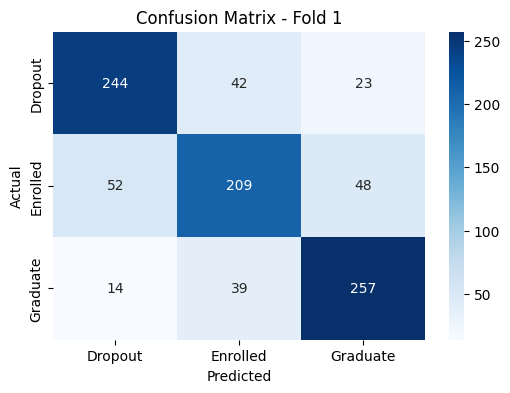


==================== FOLD 2 ====================
Accuracy   : 0.7371
F1 Macro   : 0.7342


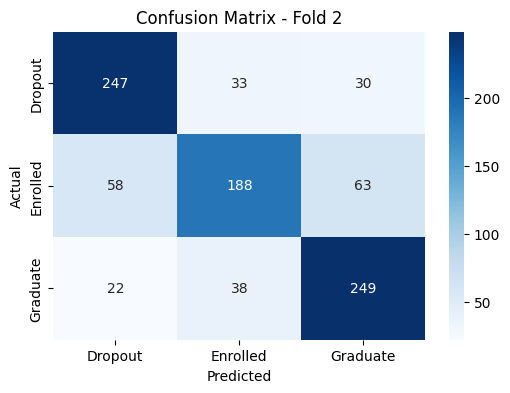


==================== FOLD 3 ====================
Accuracy   : 0.7489
F1 Macro   : 0.7467


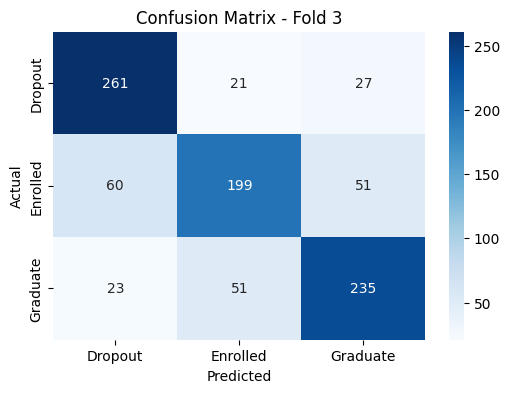


==================== FOLD 4 ====================
Accuracy   : 0.7497
F1 Macro   : 0.7472


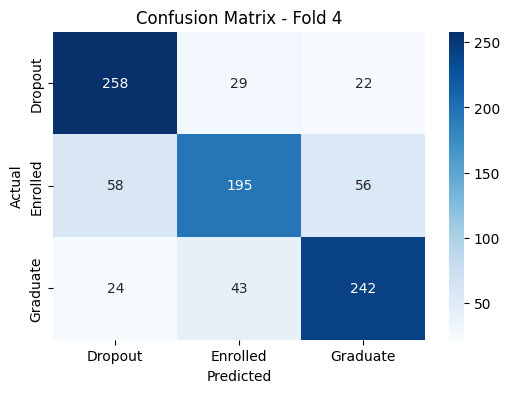


==================== FOLD 5 ====================
Accuracy   : 0.7422
F1 Macro   : 0.7404


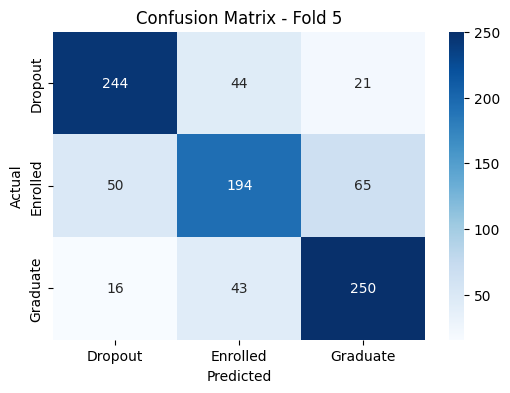


============= FINAL CROSS-VALIDATION RESULTS =============
Avg Accuracy   : 0.7486 ± 0.0095
Avg F1 Macro   : 0.7465
Avg F1 Weighted: 0.7465


In [2338]:

X = df.drop(columns=["Target"])  # Features
y = df["Target"]                # Labels

evaluate_custom_hierarchical(X, y, k=5, lr=0.1, n_iters=13000,penalty='elasticnet', solver='liblinear', C=0.03359818286283781)


In [2339]:
# def hyperparameter_tune(X_train, y_train, X_val=None, y_val=None, 
#                         cv=5, method='grid', n_iter=50, verbose=True, n_iters=1000, lr=0.01):
#     """
#     Hyperparameter tuning for MulticlassLogisticRegression
    
#     Parameters:
#     -----------
#     X_train : array-like
#         Training features
#     y_train : array-like
#         Training labels
#     X_val : array-like, optional
#         Validation features (if provided, uses hold-out validation instead of CV)
#     y_val : array-like, optional
#         Validation labels
#     cv : int
#         Number of cross-validation folds (ignored if X_val provided)
#     method : str, {'grid', 'random'}
#         'grid' for GridSearchCV, 'random' for RandomizedSearchCV
#     n_iter : int
#         Number of iterations for RandomizedSearchCV
#     verbose : bool
#         Print progress and results
#     n_iters : int
#         Number of training iterations (fixed, not tuned)
#     lr : float
#         Learning rate (fixed, not tuned)
        
#     Returns:
#     --------
#     best_model : MulticlassLogisticRegression
#         Fitted model with best hyperparameters
#     results : dict
#         Dictionary containing best parameters, best score, and cv results
#     """
#     from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
#     from sklearn.metrics import accuracy_score, classification_report
    
#     # Define parameter grid - only tune penalty, C, and solver
#     param_grid = {
#         'penalty': ['l1', 'l2', 'elasticnet', 'none'],
#         'C': np.logspace(-4, 4, 20),
#         'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga'],
#         # 'max_iter'  : [100,1000,2500,5000],
#         # 'lr' : [0.001,0.01,0.1, 0.2, 1.0]

#     }
    
#     # Initialize base model with fixed lr and n_iters
#     base_model = MulticlassLogisticRegression(
#         lr=lr,
#         n_iters=n_iters,
#         class_weight='balanced'
#     )
    
#     if verbose:
#         print("="*60)
#         print("HYPERPARAMETER TUNING")
#         print("="*60)
#         print(f"Method: {method.upper()}")
#         print(f"Parameter grid:")
#         for key, val in param_grid.items():
#             if isinstance(val, np.ndarray):
#                 print(f"  {key}: [{val[0]:.4f} ... {val[-1]:.4f}] ({len(val)} values)")
#             else:
#                 print(f"  {key}: {val}")
#         print()
    
#     # Choose search method
#     if method == 'grid':
#         search = GridSearchCV(
#             base_model,
#             param_grid,
#             cv=cv,
#             scoring='accuracy',
#             n_jobs=-1,
#             verbose=2 if verbose else 0
#         )
#     elif method == 'random':
#         search = RandomizedSearchCV(
#             base_model,
#             param_grid,
#             n_iter=n_iter,
#             cv=cv,
#             scoring='accuracy',
#             n_jobs=-1,
#             verbose=2 if verbose else 0,
#             random_state=42
#         )
#     else:
#         raise ValueError("method must be 'grid' or 'random'")
    
#     # Fit the search
#     if verbose:
#         print("Starting hyperparameter search...")
#         print()
    
#     search.fit(X_train, y_train)
    
#     # Get best model
#     best_model = search.best_estimator_
    
#     # Evaluate on validation set if provided
#     if X_val is not None and y_val is not None:
#         y_pred = best_model.predict(X_val)
#         val_accuracy = accuracy_score(y_val, y_pred)
#     else:
#         val_accuracy = None
    
#     # Compile results
#     results = {
#         'best_params': search.best_params_,
#         'best_cv_score': search.best_score_,
#         'val_accuracy': val_accuracy,
#         'cv_results': search.cv_results_
#     }
    
#     if verbose:
#         print("\n" + "="*60)
#         print("RESULTS")
#         print("="*60)
#         print(f"Best CV Score: {search.best_score_:.4f}")
#         print(f"\nBest Parameters:")
#         for key, val in search.best_params_.items():
#             print(f"  {key}: {val}")
        
#         if val_accuracy is not None:
#             print(f"\nValidation Accuracy: {val_accuracy:.4f}")
#             print("\nClassification Report (Validation Set):")
#             print(classification_report(y_val, y_pred))
        
#         print("\nTop 5 Parameter Combinations:")
#         cv_results_df = pd.DataFrame(search.cv_results_)
#         top_5 = cv_results_df.nsmallest(5, 'rank_test_score')[
#             ['rank_test_score', 'mean_test_score', 'param_penalty', 'param_C', 'param_solver']
#         ]
#         print(top_5.to_string(index=False))
#         print("="*60)
    
#     return best_model, results


# # ==================== EXAMPLE USAGE ====================

# if __name__ == "__main__":
#     # Example with synthetic data
#     from sklearn.datasets import make_classification
#     from sklearn.model_selection import train_test_split
    
#     print("Generating synthetic dataset...")
#     X, y = make_classification(
#         n_samples=1000,
#         n_features=20,
#         n_informative=15,
#         n_redundant=5,
#         n_classes=3,
#         random_state=67
#     )
    
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=67
#     )
    
#     # Method 1: Grid Search with Cross-Validation
#     print("\n" + "🔍 METHOD 1: Grid Search CV")
#     best_model_grid, results_grid = hyperparameter_tune(
#         X_train, y_train,
#         cv=5,
#         method='grid',
#         verbose=True
#     )
    
#     # Evaluate on test set
#     y_pred = best_model_grid.predict(X_test)
#     test_accuracy = accuracy_score(y_test, y_pred)
#     print(f"\n✅ Final Test Accuracy: {test_accuracy:.4f}")
    
#     print("\n" + "="*80)
    
#     # Method 2: Random Search (faster for large grids)
#     print("\n🎲 METHOD 2: Random Search CV (50 iterations)")
#     best_model_random, results_random = hyperparameter_tune(
#         X_train, y_train,
#         cv=5,
#         method='random',
#         n_iter=50,
#         verbose=True
#     )
    
#     y_pred = best_model_random.predict(X_test)
#     test_accuracy = accuracy_score(y_test, y_pred)
#     print(f"\n✅ Final Test Accuracy: {test_accuracy:.4f}")
    
#     print("\n" + "="*80)
    
#     # Method 3: With separate validation set
#     print("\n🎯 METHOD 3: Grid Search with Hold-out Validation")
#     X_tr, X_val, y_tr, y_val = train_test_split(
#         X_train, y_train, test_size=0.2, random_state=42
#     )
    
#     best_model_holdout, results_holdout = hyperparameter_tune(
#         X_tr, y_tr,
#         X_val=X_val,
#         y_val=y_val,
#         method='random',
#         n_iter=100,
#         verbose=True
#     )
    
#     y_pred = best_model_holdout.predict(X_test)
#     test_accuracy = accuracy_score(y_test, y_pred)
#     print(f"\n✅ Final Test Accuracy: {test_accuracy:.4f}")


In [2340]:
# def tune_hyperparams(df, lr_list, rl_list, iter_list):
#     results = []

#     X = df.drop(columns=["Target"])
#     y = df["Target"]

#     for lr in lr_list:
#         for it in iter_list:
#             for rl in rl_list:
#                 score = evaluate_multiclass_logreg(X, y, k=5, lr=lr, reg_lambda= rl, n_iters=it)
#                 results.append({
#                     'lr': lr,
#                     'iters': it,
#                     'reg_lambda': rl,
#                     'score': score
#                 })
#                 print(f"lr={lr}, reg_lambda={rl}, iters={it} → score={score}")

#     return sorted(results, key=lambda x: x['score'], reverse=True)
# best_hp = tune_hyperparams(
#     df,
#     lr_list=[0.4, 0.6, 0.8, 1],
#     iter_list=[20000],
#     rl_list= [0.001, 0.01, 0.1, 1, 0]
# )
# best_hp[:10]


## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

## Key Points: Proper Fit/Transform Pattern

**Why is fit/transform important?**

1. **Prevent Data Leakage**: Test data must NEVER influence preprocessing parameters
   - ❌ BAD: `scaler.fit(all_data)` - Test data leaks into training
   - ✅ GOOD: `scaler.fit(train_data)` then `scaler.transform(test_data)`

2. **Maintain Consistency**: Test data uses the SAME transformations as training
   - Min-Max scaler uses training data's min/max
   - One-hot encoder uses training data's categories
   - No new categories appear in test

3. **Oversampling Only on Training**: 
   - ✅ Oversample training data to balance classes
   - ❌ NEVER oversample test/validation data
   - This reflects real-world where test data is imbalanced

**Our Pipeline Pattern:**
```python
# Training: fit + transform + oversample
preprocessor = PreprocessingPipeline(apply_oversampling=True)
X_train_proc, y_train_proc = preprocessor.fit_transform_with_target(X_train, y_train)

# Test: transform only (uses fitted parameters)
X_test_proc = preprocessor.transform(X_test)
```

In [2341]:
import pandas as pd
import numpy as np
import os
import datetime

def create_hierarchical_submission(df, test_df, 
                                 logreg_params=None, 
                                 submission_folder='../submission'):
    """
    Train HIERARCHICAL models (Dropout vs All -> Graduate vs Enrolled) 
    and create submission file using your custom MulticlassLogisticRegression class.
    """
    
    # Default parameters (Optimized for your custom class)
    if logreg_params is None:
        logreg_params = {
            'lr': 0.1, 
            'n_iters': 2000, 
            'class_weight': 'balanced', 
            'C': 1.0, 
            'penalty': 'l2', 
            'solver': 'lbfgs' # If your class supports this
        }
    
    # Create submission folder
    os.makedirs(submission_folder, exist_ok=True)
    
    print("="*60)
    print("CREATING HIERARCHICAL SUBMISSION")
    print("Strategy: Stage 1 (Dropout vs Rest) -> Stage 2 (Graduate vs Enrolled)")
    
    # --- 1. PREPARE TRAINING DATA ---
    if "Student_ID" in df.columns:
        df_train_clean = df.drop(columns=["Student_ID"])
    else:
        df_train_clean = df.copy()
    
    y = df_train_clean["Target"]
    X = df_train_clean.drop(columns=["Target"])
    
    # --- 2. PREPARE TEST DATA ---
    test_ids = test_df["Student_ID"]
    if "Student_ID" in test_df.columns:
        X_test = test_df.drop(columns=["Student_ID"])
    else:
        X_test = test_df.copy()
        
    # Align columns (Safety check)
    X_test = X_test[X.columns]
    
    # --- 3. SCALING (Manual Z-Score to match your workflow) ---
    print("Scaling features...")
    X_mean = X.mean()
    X_std = X.std()
    
    # Avoid division by zero
    X_std = X_std.replace(0, 1)
    
    X_scaled = (X - X_mean) / X_std
    X_test_scaled = (X_test - X_mean) / X_std
    
    # Convert to numpy if your class prefers it (Safety)
    X_scaled_np = X_scaled.values
    X_test_scaled_np = X_test_scaled.values

    # =========================================================================
    # STAGE 1: DROPOUT vs NON-DROPOUT
    # =========================================================================
    print("\n[Stage 1] Training Dropout Detector...")
    
    # Create Binary Target: 1 if Dropout, 0 otherwise
    y_stage1 = (y == 'Dropout').astype(int)
    
    # Initialize and Train Model 1
    model_stage1 = MulticlassLogisticRegression(**logreg_params)
    model_stage1.fit(X_scaled_np, y_stage1)
    
    # Predict on Test Set (We need to know who is a Dropout)
    # Returns 1 (Dropout) or 0 (Safe)
    y_pred_stage1 = model_stage1.predict(X_test_scaled_np)
    
    # =========================================================================
    # STAGE 2: GRADUATE vs ENROLLED
    # =========================================================================
    print("[Stage 2] Training Status Classifier (Grad vs Enrolled)...")
    
    # Filter Training Data: Keep ONLY Non-Dropouts
    mask_non_dropout = (y != 'Dropout')
    X_stage2 = X_scaled_np[mask_non_dropout]
    y_stage2 = y[mask_non_dropout]
    
    # Initialize and Train Model 2
    model_stage2 = MulticlassLogisticRegression(**logreg_params)
    model_stage2.fit(X_stage2, y_stage2)
    
    # Predict on Test Set (Predict for everyone, we will filter later)
    # Returns 'Graduate' or 'Enrolled'
    y_pred_stage2 = model_stage2.predict(X_test_scaled_np)
    
    # =========================================================================
    # COMBINE PREDICTIONS
    # =========================================================================
    print("Combining predictions...")
    final_predictions = []
    
    for i in range(len(X_test)):
        # LOGIC:
        # If Stage 1 says Dropout (1) -> It's a Dropout.
        # If Stage 1 says Safe (0)    -> Trust Stage 2 (Grad/Enrolled).
        
        if y_pred_stage1[i] == 1:
            final_predictions.append("Dropout")
        else:
            final_predictions.append(y_pred_stage2[i])
            
    # =========================================================================
    # SAVE SUBMISSION
    # =========================================================================
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = os.path.join(submission_folder, f"submission_hierarchical_{timestamp}.csv")
    
    submission = pd.DataFrame({
        "Student_ID": test_ids,
        "Target": final_predictions
    })
    
    submission.to_csv(filename, index=False)
    
    print(f"\n✓ Submission saved as {filename}")
    print(f"✓ Total predictions: {len(final_predictions)}")
    print(f"✓ Class distribution: {submission['Target'].value_counts().to_dict()}")
    
    return submission, (model_stage1, model_stage2)

# --- RUN IT ---
submission, models = create_hierarchical_submission(
    df, 
    df_test,
    logreg_params={
        'lr': 0.1, 
        'n_iters': 13000, 
        'class_weight': 'balanced',
        'C': 0.33559818286283781, 
        'penalty': 'elasticnet', 
        'solver': 'liblinear'
    },
    submission_folder='../submission'
)

CREATING HIERARCHICAL SUBMISSION
Strategy: Stage 1 (Dropout vs Rest) -> Stage 2 (Graduate vs Enrolled)
Scaling features...

[Stage 1] Training Dropout Detector...
[Stage 2] Training Status Classifier (Grad vs Enrolled)...
Combining predictions...

✓ Submission saved as ../submission/submission_hierarchical_20251204_121031.csv
✓ Total predictions: 1328
✓ Class distribution: {'Graduate': 726, 'Dropout': 324, 'Enrolled': 278}


In [2342]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

def tune_logreg_fast(X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    param_dist = {
        "solver": ["liblinear", "lbfgs", "newton-cg", "sag", "saga"],
        "penalty": ["l1", "l2", "elasticnet"],
        "C": np.logspace(-3, 2, 20),
        "l1_ratio": np.linspace(0, 1, 10),
        "class_weight": ["balanced", None]
    }

    model = LogisticRegression(max_iter=5000, multi_class="ovr")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=2000,             # you can increase to 100
        cv=skf,
        scoring="accuracy",
        random_state=67,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X, y)

    print("Best Params:", search.best_params_)
    print("Best CV Score:", search.best_score_)

    return search.best_estimator_, search


best_model, tuner = tune_logreg_fast(X, y)

final_model = best_model.fit(X, y)  # train on full dataset
y_pred_test = final_model.predict(X_test)

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'max_iter'

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

def create_submission(df, test_df, 
                      logreg_params=None,
                      submission_folder="../submission"):
    """
    Train sklearn LogisticRegression on full training dataset and create submission.
    """

    import datetime, os

    # Default parameters
    if logreg_params is None:
        logreg_params = {
            'penalty': 'elasticnet',
            'C': 0.03,
            'solver': 'saga',
            'l1_ratio': 0.5,   # only used in elasticnet
            'max_iter': 5000,
            'class_weight': 'balanced'
        }

    os.makedirs(submission_folder, exist_ok=True)

    print("=" * 60)
    print("CREATING SUBMISSION (sklearn LogisticRegression)\n")

    # -----------------------------
    # 1. Prepare Training Data
    # -----------------------------
    df_clean = df.copy()
    if "Student_ID" in df_clean.columns:
        df_clean = df_clean.drop(columns=["Student_ID"])

    y = df_clean["Target"]
    X = df_clean.drop(columns=["Target"])

    # -----------------------------
    # 2. Standardize Training Data
    # -----------------------------
    X_mean = X.mean()
    X_std = X.std().replace(0, 1)   # prevent division by zero
    X_scaled = (X - X_mean) / X_std

    # -----------------------------
    # 3. Build sklearn logistic regression model
    # -----------------------------
    print("Training sklearn LogisticRegression...")
    model = LogisticRegression(
        **logreg_params,
        multi_class='ovr'    # OVR is usually best for imbalanced multi-class
    )

    model.fit(X_scaled, y)

    # -----------------------------
    # 4. Prepare Test Data
    # -----------------------------
    test_ids = test_df["Student_ID"]
    X_test = test_df.drop(columns=["Student_ID"])

    # Ensure same train/test columns
    missing_cols = set(X.columns) - set(X_test.columns)
    extra_cols = set(X_test.columns) - set(X.columns)

    if missing_cols:
        print(f"WARNING: Missing columns in test: {missing_cols}")
    if extra_cols:
        print(f"WARNING: Extra columns in test: {extra_cols}")

    # Reorder and fix missing columns
    for col in missing_cols:
        X_test[col] = 0  # fill missing

    X_test = X_test[X.columns]

    # Standardize test using TRAIN stats
    X_test_scaled = (X_test - X_mean) / X_std

    # -----------------------------
    # 5. Predict
    # -----------------------------
    print("\nGenerating predictions...")
    y_pred = model.predict(X_test_scaled)

    # -----------------------------
    # 6. Save submission file
    # -----------------------------
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = os.path.join(
        submission_folder, f"submission_logreg_sklearnF_{timestamp}.csv"
    )

    submission = pd.DataFrame({
        "Student_ID": test_ids,
        "Target": y_pred
    })

    submission.to_csv(filename, index=False)

    print(f"\n✓ Submission saved as {filename}")
    print(f"✓ Total predictions: {len(y_pred)}")
    print(f"✓ Class distribution:", dict(pd.Series(y_pred).value_counts()))

    return submission, model
submission, final_model = create_submission(
    df,
    df_test,
    logreg_params={
        'penalty': 'elasticnet',
        'C': 0.01,
        'solver': 'saga',
        'l1_ratio': 0.25,
        'max_iter': 2000
    }
)


CREATING SUBMISSION (sklearn LogisticRegression)

Training sklearn LogisticRegression...

Generating predictions...

✓ Submission saved as ../submission/submission_logreg_sklearnF_20251203_215004.csv
✓ Total predictions: 1328
✓ Class distribution: {'Graduate': np.int64(932), 'Dropout': np.int64(392), 'Enrolled': np.int64(4)}


In [ ]:
df.to_csv("train_res.csv", index=False)
df_test.to_csv("test_res.csv", index=False)


# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ==================== ROC ANALYSIS ====================

def plot_roc_curves(model, X_test, y_test, figsize=(12, 8), save_path=None):
    """
    Plot ROC curves for multiclass classification
    
    Parameters:
    -----------
    model : MulticlassLogisticRegression
        Trained model
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    figsize : tuple
        Figure size
    save_path : str, optional
        Path to save the figure
        
    Returns:
    --------
    roc_data : dict
        Dictionary containing ROC curve data for each class
    """
    X_test_arr = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
    y_test_arr = y_test.values if isinstance(y_test, pd.Series) else np.asarray(y_test)
    
    classes = model.classes
    n_classes = len(classes)
    
    # Get probability predictions for each class
    y_score = np.zeros((len(X_test_arr), n_classes))
    for idx, cls in enumerate(classes):
        y_score[:, idx] = model.classifiers[cls].predict_proba(X_test_arr)
    
    # Binarize the labels
    y_test_bin = label_binarize(y_test_arr, classes=classes)
    if n_classes == 2:
        y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Compute macro-average ROC curve and ROC area
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    # Plot
    plt.figure(figsize=figsize)
    
    # Plot ROC curve for each class
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown', 'pink'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
    
    # Plot micro and macro averages
    plt.plot(fpr["micro"], tpr["micro"],
            label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
            color='deeppink', linestyle=':', linewidth=3)
    
    plt.plot(fpr["macro"], tpr["macro"],
            label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})',
            color='navy', linestyle=':', linewidth=3)
    
    # Plot diagonal
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Multiclass Classification', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary
    print("="*60)
    print("ROC AUC SCORES")
    print("="*60)
    for i, cls in enumerate(classes):
        print(f"Class {cls}: {roc_auc[i]:.4f}")
    print(f"\nMicro-average: {roc_auc['micro']:.4f}")
    print(f"Macro-average: {roc_auc['macro']:.4f}")
    print("="*60)
    
    return {
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'classes': classes
    }


# ==================== SHAP ANALYSIS ====================

def compute_shap_values(model, X_train, X_test, feature_names=None, background_samples=100):
    """
    Compute SHAP values for the logistic regression model
    
    Parameters:
    -----------
    model : MulticlassLogisticRegression
        Trained model
    X_train : array-like
        Training data (used for background)
    X_test : array-like
        Test data to explain
    feature_names : list, optional
        Feature names
    background_samples : int
        Number of background samples for SHAP
        
    Returns:
    --------
    shap_values_dict : dict
        SHAP values for each class
    """
    try:
        import shap
    except ImportError:
        print("⚠️  SHAP library not installed. Install with: pip install shap")
        return None
    
    X_train_arr = X_train.values if isinstance(X_train, pd.DataFrame) else np.asarray(X_train)
    X_test_arr = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
    
    if feature_names is None:
        if isinstance(X_train, pd.DataFrame):
            feature_names = X_train.columns.tolist()
        else:
            feature_names = [f"Feature {i}" for i in range(X_train_arr.shape[1])]
    
    print("Computing SHAP values...")
    print(f"Background samples: {background_samples}")
    print(f"Test samples: {len(X_test_arr)}")
    
    # Create background dataset
    background = shap.sample(X_train_arr, background_samples)
    
    # Create prediction function for each class
    def predict_proba_all_classes(X):
        X_arr = np.asarray(X)
        probs = np.zeros((X_arr.shape[0], len(model.classes)))
        for idx, cls in enumerate(model.classes):
            probs[:, idx] = model.classifiers[cls].predict_proba(X_arr)
        return probs
    
    # Create SHAP explainer
    explainer = shap.KernelExplainer(predict_proba_all_classes, background)
    
    # Compute SHAP values
    shap_values = explainer.shap_values(X_test_arr)
    
    return {
        'shap_values': shap_values,
        'explainer': explainer,
        'feature_names': feature_names,
        'X_test': X_test_arr,
        'classes': model.classes
    }


def plot_shap_summary(shap_data, class_idx=None, plot_type='dot', figsize=(10, 8), 
                      max_display=20, save_path=None):
    """
    Plot SHAP summary plots
    
    Parameters:
    -----------
    shap_data : dict
        Dictionary returned by compute_shap_values
    class_idx : int, optional
        Class index to plot (if None, plots all classes)
    plot_type : str
        'dot' or 'bar'
    figsize : tuple
        Figure size
    max_display : int
        Maximum number of features to display
    save_path : str, optional
        Path to save the figure
    """
    try:
        import shap
    except ImportError:
        print("⚠️  SHAP library not installed.")
        return
    
    if shap_data is None:
        return
    
    shap_values = shap_data['shap_values']
    feature_names = shap_data['feature_names']
    X_test = shap_data['X_test']
    classes = shap_data['classes']
    
    if class_idx is not None:
        # Plot for specific class
        plt.figure(figsize=figsize)
        if plot_type == 'dot':
            shap.summary_plot(
                shap_values[class_idx], 
                X_test,
                feature_names=feature_names,
                max_display=max_display,
                show=False
            )
        elif plot_type == 'bar':
            shap.summary_plot(
                shap_values[class_idx], 
                X_test,
                feature_names=feature_names,
                plot_type='bar',
                max_display=max_display,
                show=False
            )
        plt.title(f'SHAP Summary - Class {classes[class_idx]}', fontsize=14, fontweight='bold')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    else:
        # Plot for all classes
        n_classes = len(classes)
        fig, axes = plt.subplots(1, n_classes, figsize=(figsize[0]*n_classes, figsize[1]))
        
        if n_classes == 1:
            axes = [axes]
        
        for idx, cls in enumerate(classes):
            plt.sca(axes[idx])
            shap.summary_plot(
                shap_values[idx], 
                X_test,
                feature_names=feature_names,
                plot_type='bar' if plot_type == 'bar' else 'dot',
                max_display=max_display,
                show=False
            )
            axes[idx].set_title(f'Class {cls}', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()


def plot_shap_waterfall(shap_data, sample_idx, class_idx, max_display=10, save_path=None):
    """
    Plot SHAP waterfall plot for a single prediction
    
    Parameters:
    -----------
    shap_data : dict
        Dictionary returned by compute_shap_values
    sample_idx : int
        Index of sample to explain
    class_idx : int
        Class index to explain
    max_display : int
        Maximum number of features to display
    save_path : str, optional
        Path to save the figure
    """
    try:
        import shap
    except ImportError:
        print("⚠️  SHAP library not installed.")
        return
    
    if shap_data is None:
        return
    
    shap_values = shap_data['shap_values']
    feature_names = shap_data['feature_names']
    X_test = shap_data['X_test']
    classes = shap_data['classes']
    explainer = shap_data['explainer']
    
    # Create explanation object
    explanation = shap.Explanation(
        values=shap_values[class_idx][sample_idx],
        base_values=explainer.expected_value[class_idx],
        data=X_test[sample_idx],
        feature_names=feature_names
    )
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(explanation, max_display=max_display, show=False)
    plt.title(f'SHAP Waterfall - Sample {sample_idx}, Class {classes[class_idx]}', 
              fontsize=14, fontweight='bold')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_shap_force(shap_data, sample_idx, class_idx, matplotlib=True, save_path=None):
    """
    Plot SHAP force plot for a single prediction
    
    Parameters:
    -----------
    shap_data : dict
        Dictionary returned by compute_shap_values
    sample_idx : int
        Index of sample to explain
    class_idx : int
        Class index to explain
    matplotlib : bool
        Use matplotlib backend (True) or JavaScript (False)
    save_path : str, optional
        Path to save the figure
    """
    try:
        import shap
    except ImportError:
        print("⚠️  SHAP library not installed.")
        return
    
    if shap_data is None:
        return
    
    shap_values = shap_data['shap_values']
    feature_names = shap_data['feature_names']
    X_test = shap_data['X_test']
    classes = shap_data['classes']
    explainer = shap_data['explainer']
    
    if matplotlib:
        shap.force_plot(
            explainer.expected_value[class_idx],
            shap_values[class_idx][sample_idx],
            X_test[sample_idx],
            feature_names=feature_names,
            matplotlib=True,
            show=False
        )
        plt.title(f'SHAP Force Plot - Sample {sample_idx}, Class {classes[class_idx]}', 
                  fontsize=14, fontweight='bold')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
    else:
        # JavaScript visualization
        return shap.force_plot(
            explainer.expected_value[class_idx],
            shap_values[class_idx][sample_idx],
            X_test[sample_idx],
            feature_names=feature_names
        )


def plot_feature_importance_comparison(shap_data, model, figsize=(12, 8), top_n=15, save_path=None):
    """
    Compare SHAP-based feature importance with model coefficients
    
    Parameters:
    -----------
    shap_data : dict
        Dictionary returned by compute_shap_values
    model : MulticlassLogisticRegression
        Trained model
    figsize : tuple
        Figure size
    top_n : int
        Number of top features to display
    save_path : str, optional
        Path to save the figure
    """
    if shap_data is None:
        return
    
    shap_values = shap_data['shap_values']
    feature_names = shap_data['feature_names']
    classes = shap_data['classes']
    n_classes = len(classes)
    
    fig, axes = plt.subplots(n_classes, 2, figsize=figsize)
    
    if n_classes == 1:
        axes = axes.reshape(1, -1)
    
    for idx, cls in enumerate(classes):
        # SHAP importance (mean absolute SHAP value)
        shap_importance = np.abs(shap_values[idx]).mean(axis=0)
        shap_df = pd.DataFrame({
            'feature': feature_names,
            'importance': shap_importance
        }).sort_values('importance', ascending=False).head(top_n)
        
        # Model coefficients
        coef_importance = np.abs(model.classifiers[cls].weights)
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'importance': coef_importance
        }).sort_values('importance', ascending=False).head(top_n)
        
        # Plot SHAP importance
        axes[idx, 0].barh(range(len(shap_df)), shap_df['importance'], color='steelblue')
        axes[idx, 0].set_yticks(range(len(shap_df)))
        axes[idx, 0].set_yticklabels(shap_df['feature'])
        axes[idx, 0].invert_yaxis()
        axes[idx, 0].set_xlabel('Mean |SHAP value|')
        axes[idx, 0].set_title(f'Class {cls} - SHAP Importance', fontweight='bold')
        axes[idx, 0].grid(alpha=0.3, axis='x')
        
        # Plot coefficient importance
        axes[idx, 1].barh(range(len(coef_df)), coef_df['importance'], color='coral')
        axes[idx, 1].set_yticks(range(len(coef_df)))
        axes[idx, 1].set_yticklabels(coef_df['feature'])
        axes[idx, 1].invert_yaxis()
        axes[idx, 1].set_xlabel('|Coefficient|')
        axes[idx, 1].set_title(f'Class {cls} - Coefficient Magnitude', fontweight='bold')
        axes[idx, 1].grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ==================== COMPREHENSIVE ANALYSIS ====================

def comprehensive_analysis(model, X_train, X_test, y_test, feature_names=None,
                          background_samples=100, save_dir=None):
    """
    Run comprehensive SHAP and ROC analysis
    
    Parameters:
    -----------
    model : MulticlassLogisticRegression
        Trained model
    X_train : array-like
        Training features
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    feature_names : list, optional
        Feature names
    background_samples : int
        Number of background samples for SHAP
    save_dir : str, optional
        Directory to save plots
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE MODEL ANALYSIS")
    print("="*80 + "\n")
    
    # ROC Analysis
    print("📊 Running ROC Analysis...")
    roc_save = f"{save_dir}/roc_curves.png" if save_dir else None
    roc_data = plot_roc_curves(model, X_test, y_test, save_path=roc_save)
    
    print("\n" + "="*80 + "\n")
    
    # SHAP Analysis
    print("🔍 Running SHAP Analysis...")
    shap_data = compute_shap_values(
        model, X_train, X_test, 
        feature_names=feature_names,
        background_samples=background_samples
    )
    
    if shap_data is not None:
        print("\n📈 Plotting SHAP Summary (Bar)...")
        shap_bar_save = f"{save_dir}/shap_summary_bar.png" if save_dir else None
        plot_shap_summary(shap_data, plot_type='bar', save_path=shap_bar_save)
        
        print("\n📈 Plotting SHAP Summary (Dot)...")
        shap_dot_save = f"{save_dir}/shap_summary_dot.png" if save_dir else None
        plot_shap_summary(shap_data, class_idx=0, plot_type='dot', save_path=shap_dot_save)
        
        print("\n📈 Plotting Feature Importance Comparison...")
        comp_save = f"{save_dir}/feature_importance_comparison.png" if save_dir else None
        plot_feature_importance_comparison(shap_data, model, save_path=comp_save)
        
        print("\n✅ Analysis complete!")
        
        return {
            'roc_data': roc_data,
            'shap_data': shap_data
        }
    else:
        print("\n⚠️  SHAP analysis skipped (library not available)")
        return {'roc_data': roc_data}


# ==================== EXAMPLE USAGE ====================

if __name__ == "__main__":
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split
    
    # Note: You'll need your MulticlassLogisticRegression from the previous artifact
    # and train a model first
    
    print("📦 Generating synthetic dataset...")
    X, y = make_classification(
        n_samples=1000,
        n_features=20,
        n_informative=15,
        n_redundant=5,
        n_classes=3,
        random_state=42
    )
    
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print("\n🎯 Training model...")
    # Replace this with your trained model from hyperparameter tuning
    model_sklearn = MulticlassLogisticRegression(X, y,  penalty='elasticnet', solver='liblinear', class_weight="balanced", C=0.03359818286283781)

    model_sklearn.fit(X_train, y_train)
    
    print("\n" + "="*80)
    print("⚠️  NOTE: This example uses sklearn's LogisticRegression")
    print("Replace with your MulticlassLogisticRegression for actual analysis")
    print("="*80)
    
    # For demonstration with sklearn model
    # You would replace this with your trained MulticlassLogisticRegression
    
    print("\n📊 Example: Plotting ROC curves...")
    # This would work with your model after adapting the interface

📦 Generating synthetic dataset...

🎯 Training model...


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'lr'

`Provide your analysis here`